# 🏦 Investor Similarity Network Analysis
**Project Phase 1: Iteration 1**

This notebook constructs a network of institutional investors based on their portfolio similarities using SEC 13F-HR data.

# 🏦 Network Analysis: Investor Similarity Tribes

## 1. Network Construction Logic
This network is built using **Portfolio Overlap** data.
*   **Nodes**: Institutional Investors (Hedge Funds, Pension Funds, Mutual Funds).
*   **Edges**: An undirected edge exists if two investors have a **Jaccard Similarity** score above a threshold (e.g., 0.15). 
*   **Jaccard Similarity**: $|A \cap B| / |A \cup B|$ (The ratio of shared stocks to the total unique stocks held by both).

## 2. Why "Investor Tribes"?
In the financial world, fund managers follow different "Investment Styles" (Growth, Value, ESG, High-Dividend). Funds with the same style will naturally have high portfolio overlap. This network captures these "Tribes" without needing to know the fund's official category.

## 3. Economic Interpretation
*   **The Edge**: Represents "Herding" behavior. If two funds are connected, they likely follow the same research, use similar algorithms, or respond to the same market signals.
*   **Communities**: These clusters represent **Investment Styles**. 
    *   Cluster 1 might be "Tech Growth" investors.
    *   Cluster 2 might be "Utility/Value" investors.
*   **Centrality**: 
    *   **Degree Centrality**: Identifies "Trendsetters"—the most standard or influential investors whose portfolios are mimicked or shared by many others.

## 4. Complex Network Metrics
*   **Clustering Coefficient**: High clustering indicates that if Investor A is similar to B, and B is similar to C, then A is likely similar to C. This proves that investment styles are well-defined categories.
*   **Connectivity**: Measures how unified the financial system is. A highly connected graph suggests that many funds are making the same bets, which can indicate **Systemic Risk** (if one fund fails, many others may be holding the same falling assets).


In [1]:
import time
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sec_api import Form13FHoldingsApi
from collections import defaultdict
import random
from community import community_louvain

In [2]:
API_KEY = 'bd15f879b366bc2da510ae1eaa6a4870901c24b4e2dcd089d8de4fd4dc3ea65c'
form13f = Form13FHoldingsApi(api_key=API_KEY)

## 1. Data Collection
We fetch 250 recent filings. Each request returns 50 filings with holdings embedded.

In [3]:
def fetch_investors(num_calls=5):
    all_investors = {}
    print(f"Starting data collection ({num_calls} API calls)...")
    
    for i in range(num_calls):
        print(f"  Call {i+1}/{num_calls}...")
        query = {
            "query": 'formType:"13F-HR"',
            "from": str(i * 50),
            "size": "50",
            "sort": [{"filedAt": {"order": "desc"}}]
        }
        response = form13f.get_data(query)
        filings = response.get("data", [])
        
        for f in filings:
            name = f.get("companyName")
            holdings = f.get("holdings", [])
            
            # Extract unique companies
            companies = {h.get("nameOfIssuer").strip().upper() for h in holdings if h.get("nameOfIssuer")}
            
            # Only keep investors with at least 30 holdings for statistical significance
            if name and len(companies) >= 30:
                all_investors[name] = companies
                
    print(f"Total investors collected: {len(all_investors)}")
    return all_investors

investors_dict = fetch_investors(5)

Starting data collection (5 API calls)...
  Call 1/5...
  Call 2/5...
  Call 3/5...
  Call 4/5...
  Call 5/5...
Total investors collected: 201


## 2. Network Construction
We use **Jaccard Similarity** to measure the overlap between two investors' portfolios. 

$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$

In [4]:
def build_investor_network(investors_dict, threshold=0.15):
    G = nx.Graph()
    investor_names = list(investors_dict.keys())
    
    # Add nodes
    for name in investor_names:
        G.add_node(name, num_holdings=len(investors_dict[name]))
        
    print(f"Calculating similarities for {len(investor_names)} nodes...")
    
    # Add edges based on Jaccard similarity
    for i in range(len(investor_names)):
        for j in range(i + 1, len(investor_names)):
            name1 = investor_names[i]
            name2 = investor_names[j]
            
            set1 = investors_dict[name1]
            set2 = investors_dict[name2]
            
            intersection = len(set1.intersection(set2))
            union = len(set1.union(set2))
            
            similarity = intersection / union
            
            if similarity >= threshold:
                G.add_edge(name1, name2, weight=similarity)
                
    # Remove isolated nodes (investors with no similar peers)
    G.remove_nodes_from(list(nx.isolates(G)))
    
    print(f"Network built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

# 0.15 is a good starting threshold to see distinct communities
G_investor = build_investor_network(investors_dict, threshold=0.15)

Calculating similarities for 201 nodes...
Network built: 163 nodes, 4574 edges


## 3. Network Analysis
We measure the fundamental properties of our Investor Network.

In [5]:
def analyze_investor_network(G):
    print("--- Basic Stats ---")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"Density: {nx.density(G):.4f}")
    print(f"Avg Degree: {np.mean([d for n, d in G.degree()]):.2f}")
    
    print("\n--- Clustering & Connectivity ---")
    print(f"Avg Clustering: {nx.average_clustering(G):.4f}")
    
    # Community Detection
    partition = community_louvain.best_partition(G)
    num_communities = len(set(partition.values()))
    print(f"Communities found (Louvain): {num_communities}")
    nx.set_node_attributes(G, partition, 'community')
    
    # Centrality
    centrality = nx.degree_centrality(G)
    top_investors = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\n--- Top 10 Central Investors (Standard-bearers) ---")
    for name, score in top_investors:
        print(f"  {name}: {score:.4f}")
        
    return partition

partition = analyze_investor_network(G_investor)

--- Basic Stats ---
Nodes: 163
Edges: 4574
Density: 0.3464
Avg Degree: 56.12

--- Clustering & Connectivity ---
Avg Clustering: 0.7461
Communities found (Louvain): 5

--- Top 10 Central Investors (Standard-bearers) ---
  Relyea Zuckerberg Hanson LLC: 0.6667
  Madison Wealth Partners, Inc: 0.6543
  DONALDSON CAPITAL MANAGEMENT, LLC: 0.6420
  Symphony Financial, Ltd. Co.: 0.6296
  Connecticut Wealth Management, LLC: 0.6235
  MARINO, STRAM & ASSOCIATES LLC: 0.6235
  Main Street Research LLC: 0.6173
  Forza Wealth Management, LLC: 0.6173
  Stenger Family Office, LLC: 0.6111
  LMCG INVESTMENTS, LLC: 0.6111


## 4. Visualization
Visualizing the communities of investors.

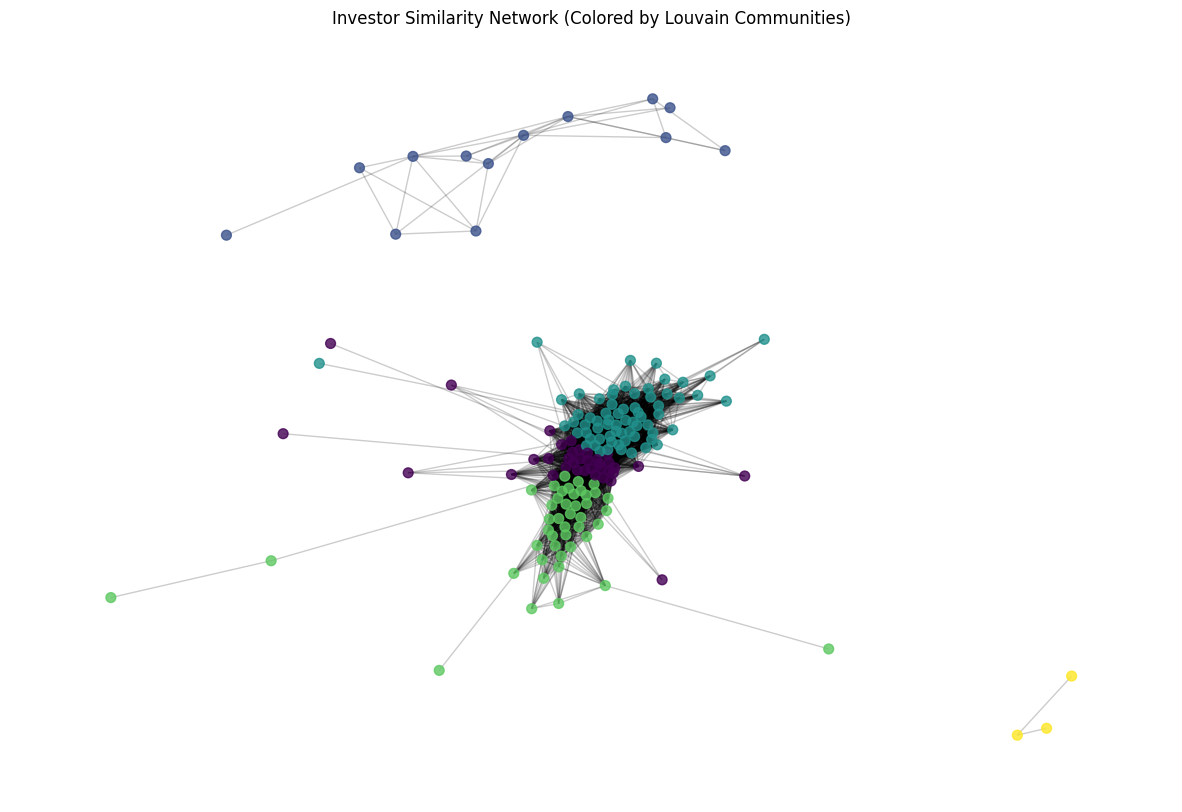

In [6]:
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G_investor, k=0.15, iterations=50)

# Color nodes by community
cmap = plt.get_cmap('viridis')
colors = [cmap(partition[node] / max(partition.values()) if partition.values() else 0) for node in G_investor.nodes()]

nx.draw_networkx_nodes(G_investor, pos, node_size=50, node_color=colors, alpha=0.8)
nx.draw_networkx_edges(G_investor, pos, alpha=0.2)

plt.title("Investor Similarity Network (Colored by Louvain Communities)")
plt.axis('off')
plt.show()

## 5. Model Comparison
How does this compare to a random graph of the same size?

In [7]:
def compare_with_random(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    p = (2 * m) / (n * (n - 1)) if n > 1 else 0
    
    er = nx.erdos_renyi_graph(n, p)
    print(f"Real Clustering: {nx.average_clustering(G):.4f}")
    print(f"Random (ER) Clustering: {nx.average_clustering(er):.4f}")
    print("\nObservation: High clustering in the real network suggests clear investment 'styles'.")

compare_with_random(G_investor)

Real Clustering: 0.7461
Random (ER) Clustering: 0.3459

Observation: High clustering in the real network suggests clear investment 'styles'.


In [8]:
nx.write_gexf(G_investor, 'investor_network.gexf')
print('Exported to GEXF for Gephi visualization.')

Exported to GEXF for Gephi visualization.
